In [1881]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OrdinalEncoder

In [1882]:
data=pd.read_csv('crime_incidents_messy.csv')

In [1883]:
data.shape

(5250, 33)

In [1884]:
data.isnull().sum()

incident_id              0
crime_type               0
district                 0
city                     0
state                    0
address                  0
latitude               258
longitude              289
incident_datetime      340
officer_id               0
officer_first_name       0
officer_last_name        0
badge_number           312
suspect_id             810
suspect_first_name     810
suspect_last_name      810
suspect_age           1097
suspect_gender        1413
suspect_race          1601
victim_id              257
victim_first_name      257
victim_last_name       257
victim_age             562
victim_gender         1000
victim_phone          1056
weapon_used            970
severity               355
case_status            731
resolution             951
num_arrests            333
property_loss_usd      436
reported_online        504
notes                 1069
dtype: int64

In [1885]:
data.columns

Index(['incident_id', 'crime_type', 'district', 'city', 'state', 'address',
       'latitude', 'longitude', 'incident_datetime', 'officer_id',
       'officer_first_name', 'officer_last_name', 'badge_number', 'suspect_id',
       'suspect_first_name', 'suspect_last_name', 'suspect_age',
       'suspect_gender', 'suspect_race', 'victim_id', 'victim_first_name',
       'victim_last_name', 'victim_age', 'victim_gender', 'victim_phone',
       'weapon_used', 'severity', 'case_status', 'resolution', 'num_arrests',
       'property_loss_usd', 'reported_online', 'notes'],
      dtype='object')

In [1886]:
data.shape

(5250, 33)

In [1887]:
print(data['crime_type'].value_counts().to_string())

crime_type
Fire Setting               84
DV                         82
ARSON                      80
Drug Offence               79
Deception                  79
KIDNAPPING                 78
Arsen                      78
trespassing                77
Hacking                    76
Dom. Violence              75
Trespassing                74
Kidnaping                  73
Roberry                    71
Drunk Driving              71
Cybercrime                 69
THEFT                      68
arson                      68
HOMICIDE                   67
Sexual Assault             67
FRAUD                      66
Abduction                  65
fraud                      65
Graffiti                   64
Fraudulent Activity        64
ROBBERY                    64
Vandlism                   64
DUII                       63
Tresspassing               63
Sexual Assualt             63
Murder                     63
Assault & Battery          62
kidnapping                 62
Trespass                   62

In [1888]:
data['crime_type'] = data['crime_type'].str.strip()
data['crime_type'] = data['crime_type'].str.replace(r'\s+', ' ', regex=True)  # fixes "CYBER  CRIME" -> "CYBER CRIME"
data['crime_type'] = data['crime_type'].str.upper()  # standardize case for comparison

In [1889]:
crime_mapping = {
    'FIRE SETTING': 'ARSON', 'ARSON': 'ARSON', 'ARSEN': 'ARSON', 'DV': 'DOMESTIC VIOLENCE', 'DOM. VIOLENCE': 'DOMESTIC VIOLENCE',
    'DOMESTIC VIOLENCE': 'DOMESTIC VIOLENCE', 'DOMESTC VIOLENCE': 'DOMESTIC VIOLENCE',
    'DRUG OFFENCE': 'DRUG OFFENSE', 'DRUG OFFENSE': 'DRUG OFFENSE',
    'DRUGS': 'DRUG OFFENSE', 'NARCOTICS': 'DRUG OFFENSE',
    'DECEPTION': 'FRAUD', 'FRAUD': 'FRAUD', 'FRAUDULENT ACTIVITY': 'FRAUD',
    'SCAM': 'FRAUD', 'ONLINE FRAUD': 'FRAUD', 'KIDNAPPING': 'KIDNAPPING', 'KIDNAPING': 'KIDNAPPING', 'ABDUCTION': 'KIDNAPPING',
    'TRESPASSING': 'TRESPASSING', 'TRESSPASSING': 'TRESPASSING', 'TRESPASS': 'TRESPASSING','HACKING': 'CYBER CRIME', 'CYBERCRIME': 'CYBER CRIME', 'CYBER CRIME': 'CYBER CRIME',
    'ROBERRY': 'ROBBERY', 'ROBBERY': 'ROBBERY', 'ROBBRY': 'ROBBERY', 'ARMED ROBBERY': 'ROBBERY',
    'DRUNK DRIVING': 'DUI', 'DUII': 'DUI', 'D.U.I.': 'DUI', 'DUI': 'DUI', 'DWI': 'DUI',
    'THEFT': 'THEFT', 'LARCENY': 'THEFT', 'THEFT/LARCENY': 'THEFT', 'STEALING': 'THEFT',
    'HOMICIDE': 'HOMICIDE', 'HOMOCIDE': 'HOMICIDE', 'MURDER': 'HOMICIDE', 'MANSLAUGHTER': 'HOMICIDE',
    'SEXUAL ASSAULT': 'SEXUAL ASSAULT', 'SEX ASSAULT': 'SEXUAL ASSAULT', 'SA': 'SEXUAL ASSAULT', 'SEXUAL ASSUALT': 'SEXUAL ASSAULT',
    'ASSAULT': 'ASSAULT', 'ASSAULT & BATTERY': 'ASSAULT', 'ASSLT': 'ASSAULT', 'BATTERY': 'ASSAULT',
    'VANDALISM': 'VANDALISM', 'VANDLISM': 'VANDALISM',  'BURGLARY': 'BURGLARY', 'BURGLRY': 'BURGLARY', 'B&E': 'BURGLARY', 
    'BREAKING & ENTERING': 'BURGLARY','GRAFFITI': 'GRAFFITI', 'PROPERTY DAMAGE': 'PROPERTY DAMAGE',
}
data['crime_type'] = data['crime_type'].map(crime_mapping).fillna(data['crime_type'])
data['crime_type'].value_counts()

crime_type
FRAUD                457
DUI                  369
ARSON                369
DRUG OFFENSE         362
HOMICIDE             357
THEFT                348
KIDNAPPING           343
SEXUAL ASSAULT       342
TRESPASSING          340
ROBBERY              334
BURGLARY             329
DOMESTIC VIOLENCE    329
ASSAULT              319
CYBER CRIME          318
VANDALISM            217
GRAFFITI              68
PROPERTY DAMAGE       49
Name: count, dtype: int64

In [1890]:
freq = data['crime_type'].value_counts()
data['crime_type'] = data['crime_type'].map(freq)

In [1891]:
data

,incident_id,crime_type,district,city,state,address,latitude,longitude,incident_datetime,officer_id,...,victim_gender,victim_phone,weapon_used,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online,notes
0,INC001115,319,Sou,Maplewood,GA,2830 Cedar Lane,170.284100,-77.500710,16/04/2024 8:45,OFF0078,...,Unknown,6223265920,Firearm,2,Open,No Arrest,NaN,NaN,TRUE,Incident at 2830 Cedar Lane. Officer responded...
1,INC004706,329,southeast,Maplewood,OH,2361 Park Rd,29.422717,-77.167016,11/01/2022 22:03,OFF0059,...,NaN,241-973-4826,Firearm,3,NaN,NaN,2.0,44839.49,yes,Incident at 2361 Park Rd. Officer responded at...
2,INC002249,357,Southwest,Lakewood,AZ,1067 Main St,39.411460,-98.615298,14/04/2022 11:39,OFF0088,...,Other,244-584-7696,KNIFE,1,CLOSED,warning,2.0,15963.38,YES,Incident at 1067 Main St. Officer responded at...
3,INC000021,49,Cen,Springfield,AZ,4713 Washington Ave,28.633439,-99.030051,09/12/2020 15:14,OFF0077,...,NaN,5021227484,hands,Low,Resolved,NaN,5.0,48680.14,FALSE,Incident at 4713 Washington Ave. Officer respo...
4,INC000488,329,North,Lakewood,PA,1371 River Rd,34.217850,-121.614731,24/07/2021 20:08,OFF0083,...,M,9698766873,Unarmed,MEDIUM,Closed,Warning Issued,2.0,23513.01,YES,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5245,INC003247,329,Nor,Springfield,OH,4434 Elm Blvd,42.576022,-79.788519,18/12/2021 17:27,OFF0005,...,m,534-870-3834,NaN,Medium,NaN,Arrest Made,2.0,44417.98,NaN,NaN
5246,INC000314,217,NORTHWEST,Maplewood,FL,1065 Sunset Blvd,38.941858,-108.480924,23/06/2023 4:09,OFF0132,...,female,NaN,NaN,2,Pending,NaN,5.0,16330.48,no,Incident at 1065 Sunset Blvd. Officer responde...
5247,INC002761,369,northwest,Fairview,FL,6419 Sunset Blvd,41.627732,-82.048681,25/04/2018 14:38,OFF0003,...,Other,796-911-1169,blunt object,4,CLOSED,NaN,4.0,13138.25,NaN,Incident at 6419 Sunset Blvd. Officer responde...
5248,INC001022,457,East,Maplewood,TX,9087 River Rd,28.903176,-111.840384,29/03/2023 9:54,OFF0028,...,female,214-897-2917,NaN,NaN,closed,arrest made,1.0,43851.12,0,Incident at 9087 River Rd. Officer responded a...


In [1892]:
print(data['district'].value_counts().to_string())


district
Nor                273
Sou                265
SOUTHWEST          106
South              102
NORTH              101
Northeast           96
Mid                 95
West                95
North               94
northwest           94
west                94
Southwest           94
Central             93
central             93
 Southeast          92
NORTHWEST           92
Cen                 92
 Northeast          92
MIDTOWN             91
NORTHEAST           90
WEST                90
 Central            90
West                89
 Midtown            89
south               89
midtown             88
North               87
southeast           87
 North              86
Midtown             86
Southwest           85
northeast           85
 West               85
 Southwest          85
East                84
 East               84
Northwest           83
Northeast           82
Wes                 82
EAST                82
CENTRAL             82
SOUTH               82
 Northwest          81
so

In [1893]:
data['district'] = data['district'].str.strip()
data['district'] = data['district'].str.replace(r'\s+', ' ', regex=True)
data['district'] = data['district'].str.upper()
district_mapping = {
    'NOR': 'NORTH', 'NORTH': 'NORTH',
    'SOU': 'SOUTH', 'SOUTH': 'SOUTH',
    'EAS': 'EAST', 'EAST': 'EAST',
    'WES': 'WEST', 'WEST': 'WEST',
    'CEN': 'CENTRAL', 'CENTRAL': 'CENTRAL',
    'MID': 'MIDTOWN', 'MIDTOWN': 'MIDTOWN',
    'NORTHEAST': 'NORTHEAST',
    'NORTHWEST': 'NORTHWEST',
    'SOUTHEAST': 'SOUTHEAST',
    'SOUTHWEST': 'SOUTHWEST',
}
data['district'] = data['district'].map(district_mapping).fillna(data['district'])
print(data['district'].value_counts())

district
NORTH        717
SOUTH        696
WEST         544
CENTRAL      542
MIDTOWN      535
EAST         473
SOUTHWEST    465
NORTHEAST    449
NORTHWEST    430
SOUTHEAST    399
Name: count, dtype: int64


In [1894]:
data['district'].nunique()

10

In [1895]:
freq = data['district'].value_counts()
data['district'] = data['district'].map(freq)

In [1896]:
data.shape

(5250, 33)

In [1897]:
print(data['city'].value_counts().to_string())

city
Riverside      740
Centerville    691
Lakewood       664
Springfield    656
Oakdale        634
Maplewood      622
Fairview       622
Hillcrest      621


In [1898]:
data['city'].nunique() #asproved above

8

In [1899]:
freq = data['city'].value_counts()
data['city'] = data['city'].map(freq)

In [1900]:
data['city'].isnull().sum()

np.int64(0)

In [1901]:
data['state'].isnull().sum()

np.int64(0)

In [1902]:
print(data['state'].value_counts().to_string())

state
FL    554
AZ    549
TX    538
NY    536
IL    535
PA    526
NC    513
GA    503
CA    501
OH    495


In [1903]:
freq = data['state'].value_counts()
data['state']=data['state'].map(freq)

In [1904]:
data['address'].nunique()

4895

In [1905]:
data['address'].head(10)

0        2830 Cedar Lane
1           2361 Park Rd
2           1067 Main St
3    4713 Washington Ave
4          1371 River Rd
5          3551 Elm Blvd
6        7394 Cedar Lane
7          1610 River Rd
8            378 Oak Ave
9           8974 Park Rd
Name: address, dtype: object

In [1906]:
data.drop (columns= ['address'], inplace = True)

In [1907]:
data['latitude'].isnull().sum()

np.int64(258)

In [1908]:
data['longitude'].isnull().sum()

np.int64(289)

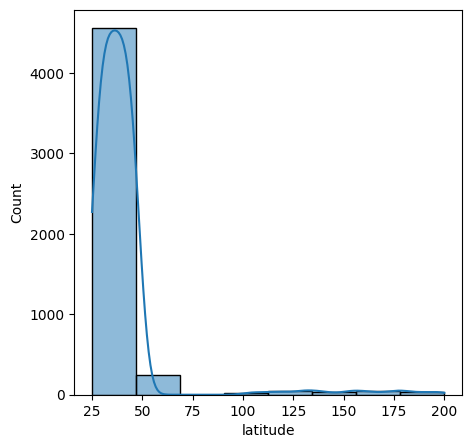

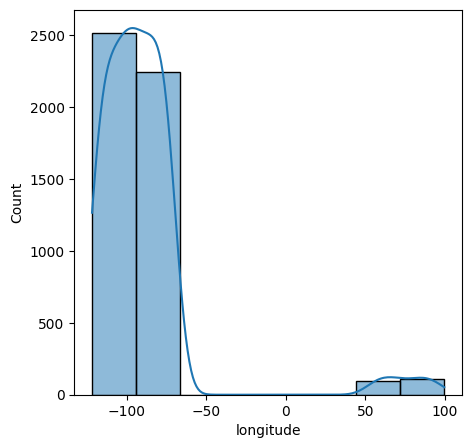

In [1909]:
intcol = ['latitude','longitude' ]
for x in intcol:
    plt.figure(figsize=(5,5))
    sns.histplot(data[x], kde = True, bins=8)

In [1910]:
data[['longitude','latitude']].describe()

,longitude,latitude
count,4961.000000,4992.000000
mean,-88.607610,40.778811
std,37.214207,23.243225
min,-121.975849,25.002420
25%,-108.040512,30.966472
50%,-94.656440,36.967123
75%,-80.588056,43.051502
max,99.787300,199.984200


In [1911]:
#both max in latitude and longitube exceeds beyond 90 and 180 which is logically impossible
data.loc[data['latitude']>90, 'latitude']= np.nan
data.loc[data['longitude']>180, 'longitude']= np.nan


In [1912]:
data[['longitude','latitude']].skew()

longitude    3.498177
latitude     0.005556
dtype: float64

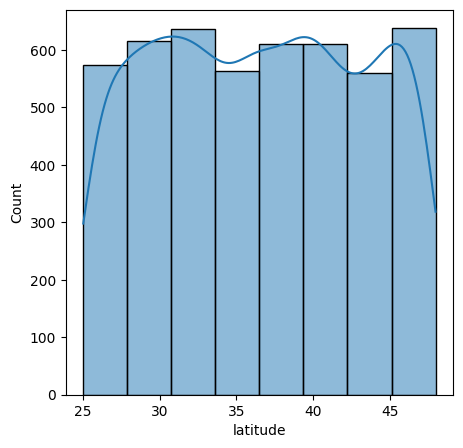

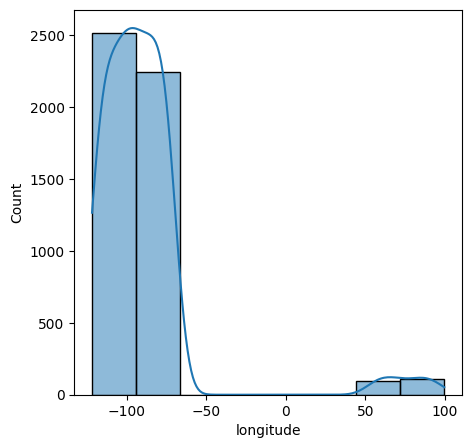

In [1913]:
intcol = ['latitude','longitude']
for x in intcol:
    plt.figure(figsize=(5,5))
    sns.histplot(data[x], kde = True, bins=8)

In [1914]:
lon_median= data['longitude'].median()
lat_median = data['latitude'].median()

data['longitude'] = data['longitude'].fillna(lon_median)
data['latitude'] = data['latitude'].fillna(lat_median)

In [1915]:
data['longitude'].value_counts()

longitude
-94.656440     290
-86.670091       3
-99.836125       3
-106.402030      3
-76.384797       2
              ... 
-79.788519       1
-108.480924      1
-82.048681       1
-111.840384      1
-78.590392       1
Name: count, Length: 4726, dtype: int64

In [1916]:
scalar= StandardScaler()
data[['latitude']] = scalar.fit_transform(data[['latitude']])
data[['longitude']] = scalar.fit_transform(data[['longitude']])

In [1917]:
data

,incident_id,crime_type,district,city,state,latitude,longitude,incident_datetime,officer_id,officer_first_name,...,victim_gender,victim_phone,weapon_used,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online,notes
0,INC001115,319,696,622,503,0.000721,0.316035,16/04/2024 8:45,OFF0078,Emily,...,Unknown,6223265920,Firearm,2,Open,No Arrest,NaN,NaN,TRUE,Incident at 2830 Cedar Lane. Officer responded...
1,INC004706,329,399,622,495,-1.117209,0.325254,11/01/2022 22:03,OFF0059,Michelle,...,NaN,241-973-4826,Firearm,3,NaN,NaN,2.0,44839.49,yes,Incident at 2361 Park Rd. Officer responded at...
2,INC002249,357,465,664,549,0.449250,-0.267271,14/04/2022 11:39,OFF0088,Michael,...,Other,244-584-7696,KNIFE,1,CLOSED,warning,2.0,15963.38,YES,Incident at 1067 Main St. Officer responded at...
3,INC000021,49,542,656,549,-1.240985,-0.278729,09/12/2020 15:14,OFF0077,Chris,...,NaN,5021227484,hands,Low,Resolved,NaN,5.0,48680.14,FALSE,Incident at 4713 Washington Ave. Officer respo...
4,INC000488,329,717,664,526,-0.365224,-0.902649,24/07/2021 20:08,OFF0083,Susan,...,M,9698766873,Unarmed,MEDIUM,Closed,Warning Issued,2.0,23513.01,YES,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5245,INC003247,329,717,656,495,0.945524,0.252833,18/12/2021 17:27,OFF0005,Matthew,...,m,534-870-3834,NaN,Medium,NaN,Arrest Made,2.0,44417.98,NaN,NaN
5246,INC000314,217,430,622,554,0.375606,-0.539817,23/06/2023 4:09,OFF0132,Patricia,...,female,NaN,NaN,2,Pending,NaN,5.0,16330.48,no,Incident at 1065 Sunset Blvd. Officer responde...
5247,INC002761,369,430,622,554,0.796811,0.190394,25/04/2018 14:38,OFF0003,Robert,...,Other,796-911-1169,blunt object,4,CLOSED,NaN,4.0,13138.25,NaN,Incident at 6419 Sunset Blvd. Officer responde...
5248,INC001022,457,473,622,538,-1.198684,-0.632625,29/03/2023 9:54,OFF0028,Chris,...,female,214-897-2917,NaN,NaN,closed,arrest made,1.0,43851.12,0,Incident at 9087 River Rd. Officer responded a...


In [1918]:
print(data['officer_first_name'].value_counts().to_string())

officer_first_name
Jessica            198
James              183
Donna              173
Michael            172
Sarah              172
Anthony            172
John               170
Mark               170
Thomas             167
Robert             167
Joseph             167
Charles            165
Susan              164
David              164
Nancy              164
Richard            162
Daniel             161
Jennifer           161
Patricia           157
Mary               157
Matthew            157
Ashley             154
Karen              151
Emily              151
Barbara            149
Carol              148
Linda              143
Chris              141
Michelle           140
William            139
michelle            10
  Barbara            9
CAROL                9
thomas               9
KAREN                9
THOMAS               8
JESSICA              8
michael              8
DANIEL               7
  Chris              7
  David              7
anthony              7
WILLIAM        

In [1919]:
data['officer_first_name'].nunique()

128

In [1920]:
columndrop = [
    'officer_first_name', 'officer_last_name', 'badge_number', 'officer_id',
    'suspect_first_name', 'suspect_last_name', 'suspect_id',
    'victim_first_name', 'victim_last_name', 'victim_id', 'victim_phone',
    'notes', 'incident_id'
]

data = data.drop(columns=columndrop)

In [1921]:
data

,crime_type,district,city,state,latitude,longitude,incident_datetime,suspect_age,suspect_gender,suspect_race,victim_age,victim_gender,weapon_used,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online
0,319,696,622,503,0.000721,0.316035,16/04/2024 8:45,51.0,MALE,asian,51.0,Unknown,Firearm,2,Open,No Arrest,NaN,NaN,TRUE
1,329,399,622,495,-1.117209,0.325254,11/01/2022 22:03,-28.0,Other,Black,231.0,NaN,Firearm,3,NaN,NaN,2.0,44839.49,yes
2,357,465,664,549,0.449250,-0.267271,14/04/2022 11:39,19.0,F,asian,29.0,Other,KNIFE,1,CLOSED,warning,2.0,15963.38,YES
3,49,542,656,549,-1.240985,-0.278729,09/12/2020 15:14,262.0,MALE,Black,243.0,NaN,hands,Low,Resolved,NaN,5.0,48680.14,FALSE
4,329,717,664,526,-0.365224,-0.902649,24/07/2021 20:08,75.0,female,white,51.0,M,Unarmed,MEDIUM,Closed,Warning Issued,2.0,23513.01,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5245,329,717,656,495,0.945524,0.252833,18/12/2021 17:27,60.0,F,White,84.0,m,NaN,Medium,NaN,Arrest Made,2.0,44417.98,NaN
5246,217,430,622,554,0.375606,-0.539817,23/06/2023 4:09,36.0,NaN,Hispanic,-75.0,female,NaN,2,Pending,NaN,5.0,16330.48,no
5247,369,430,622,554,0.796811,0.190394,25/04/2018 14:38,NaN,NaN,NaN,77.0,Other,blunt object,4,CLOSED,NaN,4.0,13138.25,NaN
5248,457,473,622,538,-1.198684,-0.632625,29/03/2023 9:54,35.0,NaN,NaN,72.0,female,NaN,NaN,closed,arrest made,1.0,43851.12,0


In [1922]:
negative_cnt = (data['suspect_age'] < 0).sum()
nan_count = data['suspect_age'].isnull().sum()
young = (data['suspect_age'] < 5).sum()  
old = (data['suspect_age'] > 85).sum()


In [1923]:
young

np.int64(173)

In [1924]:
old

np.int64(160)

In [1925]:
negative_cnt

np.int64(173)

In [1926]:
nan_count

np.int64(1097)

In [1927]:
# does NaN age correlate with a status/outcome column?
data[data['suspect_age'].isnull()]['case_status'].value_counts()

case_status
open                   86
Pending                85
Investgation           84
Under Investigation    83
Open                   80
OPEN                   80
under investigation    79
Closed                 78
Resolved               75
Pendng                 73
closed                 72
CLOSED                 71
Name: count, dtype: int64

In [1928]:
data['case_status'] = data['case_status'].str.lower().str.strip()
status = {
    'invstgation': 'under investigation',
    'under investigation': 'under investigation',
    'pendng': 'pending',
    'pending': 'pending',
    'open': 'open',
    'closed': 'closed',
    'resolved': 'resolved'
}
data['case_status'] = data['case_status'].map(status)

In [1929]:
data[data['suspect_age'].isnull()]['case_status'].value_counts()

case_status
open                   246
closed                 221
under investigation    162
pending                158
resolved                75
Name: count, dtype: int64

In [1930]:
data = data[(data['suspect_age'] >= 5) & (data['suspect_age'] <= 85)]

In [1931]:
data['suspect_age'].isnull().sum()

np.int64(0)

In [1932]:
print(data['suspect_age'].min(),data['suspect_age'].max())


15.0 75.0


In [1933]:
data

,crime_type,district,city,state,latitude,longitude,incident_datetime,suspect_age,suspect_gender,suspect_race,victim_age,victim_gender,weapon_used,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online
0,319,696,622,503,0.000721,0.316035,16/04/2024 8:45,51.0,MALE,asian,51.0,Unknown,Firearm,2,open,No Arrest,NaN,NaN,TRUE
2,357,465,664,549,0.449250,-0.267271,14/04/2022 11:39,19.0,F,asian,29.0,Other,KNIFE,1,closed,warning,2.0,15963.38,YES
4,329,717,664,526,-0.365224,-0.902649,24/07/2021 20:08,75.0,female,white,51.0,M,Unarmed,MEDIUM,closed,Warning Issued,2.0,23513.01,YES
5,329,473,621,501,1.237619,-0.354564,05/03/2020,73.0,NaN,White,15.0,NaN,Blunt Object,high,under investigation,arrest made,1.0,NaN,YES
6,334,399,622,538,0.310363,-0.032036,03/10/2021 5:17,58.0,Female,Unknown,72.0,female,Blunt Object,NaN,closed,warning,3.0,NaN,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5243,348,430,656,526,1.193289,-0.389735,NaN,29.0,MALE,white,90.0,female,NaN,Low,under investigation,warning,4.0,13704.95,1
5244,369,535,622,495,0.889385,0.518121,25/03/2020 5:55,41.0,Female,Hispanic,30.0,FEMALE,Knife,high,NaN,NO ARREST,5.0,25945.77,yes
5245,329,717,656,495,0.945524,0.252833,18/12/2021 17:27,60.0,F,White,84.0,m,NaN,Medium,NaN,Arrest Made,2.0,44417.98,NaN
5246,217,430,622,554,0.375606,-0.539817,23/06/2023 4:09,36.0,NaN,Hispanic,-75.0,female,NaN,2,pending,NaN,5.0,16330.48,no


In [1934]:
data['suspect_gender'].nunique()

12

In [1935]:
data['suspect_gender'].isnull().sum()

np.int64(534)

In [1936]:
data['suspect_gender'].value_counts()

suspect_gender
F          311
male       286
female     285
Unknown    276
f          273
Female     272
m          272
Other      269
FEMALE     268
M          267
Male       254
MALE       253
Name: count, dtype: int64

In [1937]:
gender_status = {
    'F': 'female',
    'female': 'female',
    'f': 'female',
    'Female': 'female',
    'Other': 'other',
    'FEMALE': 'female',
    'm':'male',
    'M':'male',
    'Male':'male',
    'MALE':'male',
    'male':'male',
    'Unknown': 'unknown'
}
data['suspect_gender'] = data['suspect_gender'].map(gender_status)

In [1938]:
data['suspect_gender'].unique()

array(['male', 'female', nan, 'other', 'unknown'], dtype=object)

In [1939]:
data['suspect_gender'].isnull().sum()

np.int64(534)

In [1940]:
data['suspect_gender']= data['suspect_gender'].fillna('unknown')

In [1941]:
data['suspect_gender'].isnull().sum()

np.int64(0)

In [1942]:
data['suspect_gender'].unique()

array(['male', 'female', 'unknown', 'other'], dtype=object)

In [1943]:
data

,crime_type,district,city,state,latitude,longitude,incident_datetime,suspect_age,suspect_gender,suspect_race,victim_age,victim_gender,weapon_used,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online
0,319,696,622,503,0.000721,0.316035,16/04/2024 8:45,51.0,male,asian,51.0,Unknown,Firearm,2,open,No Arrest,NaN,NaN,TRUE
2,357,465,664,549,0.449250,-0.267271,14/04/2022 11:39,19.0,female,asian,29.0,Other,KNIFE,1,closed,warning,2.0,15963.38,YES
4,329,717,664,526,-0.365224,-0.902649,24/07/2021 20:08,75.0,female,white,51.0,M,Unarmed,MEDIUM,closed,Warning Issued,2.0,23513.01,YES
5,329,473,621,501,1.237619,-0.354564,05/03/2020,73.0,unknown,White,15.0,NaN,Blunt Object,high,under investigation,arrest made,1.0,NaN,YES
6,334,399,622,538,0.310363,-0.032036,03/10/2021 5:17,58.0,female,Unknown,72.0,female,Blunt Object,NaN,closed,warning,3.0,NaN,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5243,348,430,656,526,1.193289,-0.389735,NaN,29.0,male,white,90.0,female,NaN,Low,under investigation,warning,4.0,13704.95,1
5244,369,535,622,495,0.889385,0.518121,25/03/2020 5:55,41.0,female,Hispanic,30.0,FEMALE,Knife,high,NaN,NO ARREST,5.0,25945.77,yes
5245,329,717,656,495,0.945524,0.252833,18/12/2021 17:27,60.0,female,White,84.0,m,NaN,Medium,NaN,Arrest Made,2.0,44417.98,NaN
5246,217,430,622,554,0.375606,-0.539817,23/06/2023 4:09,36.0,unknown,Hispanic,-75.0,female,NaN,2,pending,NaN,5.0,16330.48,no


In [1944]:
data['suspect_race'].unique()

array(['asian', 'white', 'White', 'Unknown', 'Hispanic', 'BLACK', 'Asian',
       nan, 'Black', 'Other', 'hispanic'], dtype=object)

In [1945]:
race_status={
  'asian': 'asian',
  'white': 'white',
  'White':'white',
  'Unknown':'unknown',
  'Hispanic':'hispanic',
   'BLACK':'black',
   'Asian':'asian',
    'Black':'black',
    'Other':'other',
 'hispanic':'hispanic'
}
data['suspect_race']=data['suspect_race'].map(race_status)

In [1946]:
data['suspect_race'].unique()

array(['asian', 'white', 'unknown', 'hispanic', 'black', nan, 'other'],
      dtype=object)

In [1947]:
data['suspect_race'].isnull().sum()

np.int64(679)

In [1948]:
data['suspect_race']=data['suspect_race'].fillna('unknown')

In [1949]:
data['suspect_race'].isnull().sum()

np.int64(0)

In [1950]:
data

,crime_type,district,city,state,latitude,longitude,incident_datetime,suspect_age,suspect_gender,suspect_race,victim_age,victim_gender,weapon_used,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online
0,319,696,622,503,0.000721,0.316035,16/04/2024 8:45,51.0,male,asian,51.0,Unknown,Firearm,2,open,No Arrest,NaN,NaN,TRUE
2,357,465,664,549,0.449250,-0.267271,14/04/2022 11:39,19.0,female,asian,29.0,Other,KNIFE,1,closed,warning,2.0,15963.38,YES
4,329,717,664,526,-0.365224,-0.902649,24/07/2021 20:08,75.0,female,white,51.0,M,Unarmed,MEDIUM,closed,Warning Issued,2.0,23513.01,YES
5,329,473,621,501,1.237619,-0.354564,05/03/2020,73.0,unknown,white,15.0,NaN,Blunt Object,high,under investigation,arrest made,1.0,NaN,YES
6,334,399,622,538,0.310363,-0.032036,03/10/2021 5:17,58.0,female,unknown,72.0,female,Blunt Object,NaN,closed,warning,3.0,NaN,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5243,348,430,656,526,1.193289,-0.389735,NaN,29.0,male,white,90.0,female,NaN,Low,under investigation,warning,4.0,13704.95,1
5244,369,535,622,495,0.889385,0.518121,25/03/2020 5:55,41.0,female,hispanic,30.0,FEMALE,Knife,high,NaN,NO ARREST,5.0,25945.77,yes
5245,329,717,656,495,0.945524,0.252833,18/12/2021 17:27,60.0,female,white,84.0,m,NaN,Medium,NaN,Arrest Made,2.0,44417.98,NaN
5246,217,430,622,554,0.375606,-0.539817,23/06/2023 4:09,36.0,unknown,hispanic,-75.0,female,NaN,2,pending,NaN,5.0,16330.48,no


In [1951]:
data['victim_age'].isnull().sum()

np.int64(414)

In [1952]:
data.shape

(3820, 19)

In [1953]:
data[data['victim_age'].isnull()]['case_status'].value_counts()

case_status
closed                 92
open                   82
under investigation    66
pending                50
resolved               29
Name: count, dtype: int64

In [1954]:
data['victim_age'].value_counts()

victim_age
 67.0     55
 21.0     54
 15.0     54
 33.0     52
 32.0     49
          ..
-52.0      1
 165.0     1
 234.0     1
-39.0      1
 194.0     1
Name: count, Length: 233, dtype: int64

In [1955]:
data['victim_age'].min()

np.float64(-90.0)

In [1956]:
data['victim_age'].max()

np.float64(298.0)

In [1957]:
data['victim_age'].min()

np.float64(-90.0)

In [1958]:
data.loc[(data['victim_age']< 1)|(data['victim_age'] > 90),'victim_age']=np.nan

In [1959]:
data['victim_age'].max()

np.float64(90.0)

In [1960]:
age_median =data['victim_age'].median()

In [1961]:
data['victim_age']= data['victim_age'].fillna(age_median)

In [1962]:
data.shape

(3820, 19)

In [1963]:
data['victim_age'].isnull().sum()

np.int64(0)

In [1964]:
data

,crime_type,district,city,state,latitude,longitude,incident_datetime,suspect_age,suspect_gender,suspect_race,victim_age,victim_gender,weapon_used,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online
0,319,696,622,503,0.000721,0.316035,16/04/2024 8:45,51.0,male,asian,51.0,Unknown,Firearm,2,open,No Arrest,NaN,NaN,TRUE
2,357,465,664,549,0.449250,-0.267271,14/04/2022 11:39,19.0,female,asian,29.0,Other,KNIFE,1,closed,warning,2.0,15963.38,YES
4,329,717,664,526,-0.365224,-0.902649,24/07/2021 20:08,75.0,female,white,51.0,M,Unarmed,MEDIUM,closed,Warning Issued,2.0,23513.01,YES
5,329,473,621,501,1.237619,-0.354564,05/03/2020,73.0,unknown,white,15.0,NaN,Blunt Object,high,under investigation,arrest made,1.0,NaN,YES
6,334,399,622,538,0.310363,-0.032036,03/10/2021 5:17,58.0,female,unknown,72.0,female,Blunt Object,NaN,closed,warning,3.0,NaN,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5243,348,430,656,526,1.193289,-0.389735,NaN,29.0,male,white,90.0,female,NaN,Low,under investigation,warning,4.0,13704.95,1
5244,369,535,622,495,0.889385,0.518121,25/03/2020 5:55,41.0,female,hispanic,30.0,FEMALE,Knife,high,NaN,NO ARREST,5.0,25945.77,yes
5245,329,717,656,495,0.945524,0.252833,18/12/2021 17:27,60.0,female,white,84.0,m,NaN,Medium,NaN,Arrest Made,2.0,44417.98,NaN
5246,217,430,622,554,0.375606,-0.539817,23/06/2023 4:09,36.0,unknown,hispanic,50.0,female,NaN,2,pending,NaN,5.0,16330.48,no


In [1965]:
data['victim_gender'].nunique()

12

In [1966]:
data['victim_gender'].value_counts()

victim_gender
female     291
Male       278
M          274
Unknown    268
Other      265
m          261
MALE       257
male       250
FEMALE     245
f          238
F          235
Female     232
Name: count, dtype: int64

In [1967]:
victim_status = {
    'F': 'female',
    'female': 'female',
    'f': 'female',
    'Female': 'female',
    'Other': 'other',
    'FEMALE': 'female',
    'm':'male',
    'M':'male',
    'Male':'male',
    'MALE':'male',
    'male':'male',
    'Unknown': 'unknown'
}
data['victim_gender'] = data['victim_gender'].map(victim_status)


In [1968]:
data['victim_gender'].value_counts()

victim_gender
male       1320
female     1241
unknown     268
other       265
Name: count, dtype: int64

In [1969]:
data['victim_gender'].nunique()

4

In [1970]:
data['victim_gender']=data['victim_gender'].fillna('unknown')

In [1971]:
data

,crime_type,district,city,state,latitude,longitude,incident_datetime,suspect_age,suspect_gender,suspect_race,victim_age,victim_gender,weapon_used,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online
0,319,696,622,503,0.000721,0.316035,16/04/2024 8:45,51.0,male,asian,51.0,unknown,Firearm,2,open,No Arrest,NaN,NaN,TRUE
2,357,465,664,549,0.449250,-0.267271,14/04/2022 11:39,19.0,female,asian,29.0,other,KNIFE,1,closed,warning,2.0,15963.38,YES
4,329,717,664,526,-0.365224,-0.902649,24/07/2021 20:08,75.0,female,white,51.0,male,Unarmed,MEDIUM,closed,Warning Issued,2.0,23513.01,YES
5,329,473,621,501,1.237619,-0.354564,05/03/2020,73.0,unknown,white,15.0,unknown,Blunt Object,high,under investigation,arrest made,1.0,NaN,YES
6,334,399,622,538,0.310363,-0.032036,03/10/2021 5:17,58.0,female,unknown,72.0,female,Blunt Object,NaN,closed,warning,3.0,NaN,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5243,348,430,656,526,1.193289,-0.389735,NaN,29.0,male,white,90.0,female,NaN,Low,under investigation,warning,4.0,13704.95,1
5244,369,535,622,495,0.889385,0.518121,25/03/2020 5:55,41.0,female,hispanic,30.0,female,Knife,high,NaN,NO ARREST,5.0,25945.77,yes
5245,329,717,656,495,0.945524,0.252833,18/12/2021 17:27,60.0,female,white,84.0,male,NaN,Medium,NaN,Arrest Made,2.0,44417.98,NaN
5246,217,430,622,554,0.375606,-0.539817,23/06/2023 4:09,36.0,unknown,hispanic,50.0,female,NaN,2,pending,NaN,5.0,16330.48,no


In [1972]:
data['weapon_used'].isnull().sum()

np.int64(706)

In [1973]:
data['weapon_used'].nunique()

13

In [1974]:
data['weapon_used'].value_counts()

weapon_used
Hands/Feet      266
Unarmed         265
KNIFE           262
Rifle           252
Blunt Object    244
Knife           237
Firearm         234
blunt object    233
Pistol          233
Gun             226
Bat             226
firearm         220
hands           216
Name: count, dtype: int64

In [1975]:
weapon = {
    'Hands/Feet': 'unarmed',
    'Unarmed': 'unarmed',
    'hands': 'unarmed',
    'KNIFE': 'knife',
    'Knife': 'knife',
    'Rifle': 'firearm',
    'Blunt Object': 'blunt object',
    'blunt object': 'blunt object',
    'Bat': 'blunt object',
    'Firearm': 'firearm',
    'firearm': 'firearm',
    'Gun': 'firearm',
    'Pistol': 'firearm'
}

data['weapon_used'] = data['weapon_used'].replace(weapon)
print(data['weapon_used'].value_counts())

weapon_used
firearm         1165
unarmed          747
blunt object     703
knife            499
Name: count, dtype: int64


In [1976]:
data['weapon_used'] = data['weapon_used'].fillna('unknown')

In [1977]:
print(data['weapon_used'].value_counts())

weapon_used
firearm         1165
unarmed          747
unknown          706
blunt object     703
knife            499
Name: count, dtype: int64


In [1978]:
data

,crime_type,district,city,state,latitude,longitude,incident_datetime,suspect_age,suspect_gender,suspect_race,victim_age,victim_gender,weapon_used,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online
0,319,696,622,503,0.000721,0.316035,16/04/2024 8:45,51.0,male,asian,51.0,unknown,firearm,2,open,No Arrest,NaN,NaN,TRUE
2,357,465,664,549,0.449250,-0.267271,14/04/2022 11:39,19.0,female,asian,29.0,other,knife,1,closed,warning,2.0,15963.38,YES
4,329,717,664,526,-0.365224,-0.902649,24/07/2021 20:08,75.0,female,white,51.0,male,unarmed,MEDIUM,closed,Warning Issued,2.0,23513.01,YES
5,329,473,621,501,1.237619,-0.354564,05/03/2020,73.0,unknown,white,15.0,unknown,blunt object,high,under investigation,arrest made,1.0,NaN,YES
6,334,399,622,538,0.310363,-0.032036,03/10/2021 5:17,58.0,female,unknown,72.0,female,blunt object,NaN,closed,warning,3.0,NaN,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5243,348,430,656,526,1.193289,-0.389735,NaN,29.0,male,white,90.0,female,unknown,Low,under investigation,warning,4.0,13704.95,1
5244,369,535,622,495,0.889385,0.518121,25/03/2020 5:55,41.0,female,hispanic,30.0,female,knife,high,NaN,NO ARREST,5.0,25945.77,yes
5245,329,717,656,495,0.945524,0.252833,18/12/2021 17:27,60.0,female,white,84.0,male,unknown,Medium,NaN,Arrest Made,2.0,44417.98,NaN
5246,217,430,622,554,0.375606,-0.539817,23/06/2023 4:09,36.0,unknown,hispanic,50.0,female,unknown,2,pending,NaN,5.0,16330.48,no


In [1979]:
data['severity'].value_counts()

severity
3           268
low         266
1           265
4           261
MEDIUM      261
Med         260
high        257
Crit        257
CRITICAL    254
Medium      254
Low         248
Critical    236
2           235
High        233
Name: count, dtype: int64

In [1980]:
data.groupby('severity')['case_status'].value_counts(normalize=True)

severity  case_status        
1         closed                 0.256881
          open                   0.238532
          pending                0.188073
          under investigation    0.183486
          resolved               0.133028
                                   ...   
low       closed                 0.331754
          open                   0.218009
          under investigation    0.194313
          pending                0.165877
          resolved               0.090047
Name: proportion, Length: 70, dtype: float64

In [1981]:
print(data['severity'].dtype)


object


In [1982]:
severity_count = {
    '1': 'low',
    '2': 'medium',
    '3': 'high', '4': 'critical',
    'low': 'low', 'Low': 'low',
    'MEDIUM': 'medium', 'Med': 'medium', 'Medium': 'medium',
    'high': 'high', 'High': 'high',
    'CRITICAL': 'critical', 'Critical': 'critical', 'Crit': 'critical'
}
data['severity']= data['severity'].replace(severity_count)



In [1983]:
data['severity'].value_counts()


severity
medium      1010
critical    1008
low          779
high         758
Name: count, dtype: int64

In [1984]:
data['severity'].isnull().sum()



np.int64(265)

In [1985]:
data['severity']= data['severity'].fillna('unknown')
data['severity'].isnull().sum()


np.int64(0)

In [1986]:
data

,crime_type,district,city,state,latitude,longitude,incident_datetime,suspect_age,suspect_gender,suspect_race,victim_age,victim_gender,weapon_used,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online
0,319,696,622,503,0.000721,0.316035,16/04/2024 8:45,51.0,male,asian,51.0,unknown,firearm,medium,open,No Arrest,NaN,NaN,TRUE
2,357,465,664,549,0.449250,-0.267271,14/04/2022 11:39,19.0,female,asian,29.0,other,knife,low,closed,warning,2.0,15963.38,YES
4,329,717,664,526,-0.365224,-0.902649,24/07/2021 20:08,75.0,female,white,51.0,male,unarmed,medium,closed,Warning Issued,2.0,23513.01,YES
5,329,473,621,501,1.237619,-0.354564,05/03/2020,73.0,unknown,white,15.0,unknown,blunt object,high,under investigation,arrest made,1.0,NaN,YES
6,334,399,622,538,0.310363,-0.032036,03/10/2021 5:17,58.0,female,unknown,72.0,female,blunt object,unknown,closed,warning,3.0,NaN,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5243,348,430,656,526,1.193289,-0.389735,NaN,29.0,male,white,90.0,female,unknown,low,under investigation,warning,4.0,13704.95,1
5244,369,535,622,495,0.889385,0.518121,25/03/2020 5:55,41.0,female,hispanic,30.0,female,knife,high,NaN,NO ARREST,5.0,25945.77,yes
5245,329,717,656,495,0.945524,0.252833,18/12/2021 17:27,60.0,female,white,84.0,male,unknown,medium,NaN,Arrest Made,2.0,44417.98,NaN
5246,217,430,622,554,0.375606,-0.539817,23/06/2023 4:09,36.0,unknown,hispanic,50.0,female,unknown,medium,pending,NaN,5.0,16330.48,no


In [1987]:
data['resolution'].isnull().sum()


np.int64(648)

In [1988]:
data['resolution'].value_counts()


resolution
Arrest Made       371
arrest made       362
No Arrest         361
Warning Issued    361
warning           353
Arres Made        351
Dismissed         351
Case Dismissed    343
NO ARREST         319
Name: count, dtype: int64

In [1989]:
resolution_count = {
'Arrest Made': 'ArrestMade',
'arrest made':'ArrestMade',
'No Arrest':'No Arrest',
'Warning Issued' : 'Warning Issued',
'warning': 'Warning Issued',       
'Arres Made':'ArrestMade',     
'Dismissed':'CaseDismissed',
'Case Dismissed':'CaseDismissed',
'NO ARREST':'No Arrest'  
}
data['resolution']= data['resolution'].replace(resolution_count)

In [1990]:
data['resolution']=data['resolution'].fillna('unknown')


In [1991]:
data['resolution'].value_counts()


resolution
ArrestMade        1084
Warning Issued     714
CaseDismissed      694
No Arrest          680
unknown            648
Name: count, dtype: int64

In [1992]:
data['resolution'].isnull().sum()


np.int64(0)

In [1993]:
data

,crime_type,district,city,state,latitude,longitude,incident_datetime,suspect_age,suspect_gender,suspect_race,victim_age,victim_gender,weapon_used,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online
0,319,696,622,503,0.000721,0.316035,16/04/2024 8:45,51.0,male,asian,51.0,unknown,firearm,medium,open,No Arrest,NaN,NaN,TRUE
2,357,465,664,549,0.449250,-0.267271,14/04/2022 11:39,19.0,female,asian,29.0,other,knife,low,closed,Warning Issued,2.0,15963.38,YES
4,329,717,664,526,-0.365224,-0.902649,24/07/2021 20:08,75.0,female,white,51.0,male,unarmed,medium,closed,Warning Issued,2.0,23513.01,YES
5,329,473,621,501,1.237619,-0.354564,05/03/2020,73.0,unknown,white,15.0,unknown,blunt object,high,under investigation,ArrestMade,1.0,NaN,YES
6,334,399,622,538,0.310363,-0.032036,03/10/2021 5:17,58.0,female,unknown,72.0,female,blunt object,unknown,closed,Warning Issued,3.0,NaN,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5243,348,430,656,526,1.193289,-0.389735,NaN,29.0,male,white,90.0,female,unknown,low,under investigation,Warning Issued,4.0,13704.95,1
5244,369,535,622,495,0.889385,0.518121,25/03/2020 5:55,41.0,female,hispanic,30.0,female,knife,high,NaN,No Arrest,5.0,25945.77,yes
5245,329,717,656,495,0.945524,0.252833,18/12/2021 17:27,60.0,female,white,84.0,male,unknown,medium,NaN,ArrestMade,2.0,44417.98,NaN
5246,217,430,622,554,0.375606,-0.539817,23/06/2023 4:09,36.0,unknown,hispanic,50.0,female,unknown,medium,pending,unknown,5.0,16330.48,no


In [1994]:
data['num_arrests'].isnull().sum()


np.int64(226)

In [1995]:
data['num_arrests'] = data['num_arrests'].fillna(0)

In [1996]:
data

,crime_type,district,city,state,latitude,longitude,incident_datetime,suspect_age,suspect_gender,suspect_race,victim_age,victim_gender,weapon_used,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online
0,319,696,622,503,0.000721,0.316035,16/04/2024 8:45,51.0,male,asian,51.0,unknown,firearm,medium,open,No Arrest,0.0,NaN,TRUE
2,357,465,664,549,0.449250,-0.267271,14/04/2022 11:39,19.0,female,asian,29.0,other,knife,low,closed,Warning Issued,2.0,15963.38,YES
4,329,717,664,526,-0.365224,-0.902649,24/07/2021 20:08,75.0,female,white,51.0,male,unarmed,medium,closed,Warning Issued,2.0,23513.01,YES
5,329,473,621,501,1.237619,-0.354564,05/03/2020,73.0,unknown,white,15.0,unknown,blunt object,high,under investigation,ArrestMade,1.0,NaN,YES
6,334,399,622,538,0.310363,-0.032036,03/10/2021 5:17,58.0,female,unknown,72.0,female,blunt object,unknown,closed,Warning Issued,3.0,NaN,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5243,348,430,656,526,1.193289,-0.389735,NaN,29.0,male,white,90.0,female,unknown,low,under investigation,Warning Issued,4.0,13704.95,1
5244,369,535,622,495,0.889385,0.518121,25/03/2020 5:55,41.0,female,hispanic,30.0,female,knife,high,NaN,No Arrest,5.0,25945.77,yes
5245,329,717,656,495,0.945524,0.252833,18/12/2021 17:27,60.0,female,white,84.0,male,unknown,medium,NaN,ArrestMade,2.0,44417.98,NaN
5246,217,430,622,554,0.375606,-0.539817,23/06/2023 4:09,36.0,unknown,hispanic,50.0,female,unknown,medium,pending,unknown,5.0,16330.48,no


In [1997]:
data['property_loss_usd'].dtype

dtype('O')

In [1998]:
data['property_loss_usd']=pd.to_numeric(data['property_loss_usd'], errors='coerce')

In [1999]:
data['property_loss_usd'].dtype

dtype('float64')

In [2000]:
data['property_loss_usd'].isnull().sum()


np.int64(420)

In [2001]:
propertymed = data['property_loss_usd'].median()
data['property_loss_usd']= data['property_loss_usd'].fillna(propertymed)

In [2002]:
data['property_loss_usd'].isnull().sum()

np.int64(0)

In [2003]:
data

,crime_type,district,city,state,latitude,longitude,incident_datetime,suspect_age,suspect_gender,suspect_race,victim_age,victim_gender,weapon_used,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online
0,319,696,622,503,0.000721,0.316035,16/04/2024 8:45,51.0,male,asian,51.0,unknown,firearm,medium,open,No Arrest,0.0,23698.135,TRUE
2,357,465,664,549,0.449250,-0.267271,14/04/2022 11:39,19.0,female,asian,29.0,other,knife,low,closed,Warning Issued,2.0,15963.380,YES
4,329,717,664,526,-0.365224,-0.902649,24/07/2021 20:08,75.0,female,white,51.0,male,unarmed,medium,closed,Warning Issued,2.0,23513.010,YES
5,329,473,621,501,1.237619,-0.354564,05/03/2020,73.0,unknown,white,15.0,unknown,blunt object,high,under investigation,ArrestMade,1.0,23698.135,YES
6,334,399,622,538,0.310363,-0.032036,03/10/2021 5:17,58.0,female,unknown,72.0,female,blunt object,unknown,closed,Warning Issued,3.0,23698.135,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5243,348,430,656,526,1.193289,-0.389735,NaN,29.0,male,white,90.0,female,unknown,low,under investigation,Warning Issued,4.0,13704.950,1
5244,369,535,622,495,0.889385,0.518121,25/03/2020 5:55,41.0,female,hispanic,30.0,female,knife,high,NaN,No Arrest,5.0,25945.770,yes
5245,329,717,656,495,0.945524,0.252833,18/12/2021 17:27,60.0,female,white,84.0,male,unknown,medium,NaN,ArrestMade,2.0,44417.980,NaN
5246,217,430,622,554,0.375606,-0.539817,23/06/2023 4:09,36.0,unknown,hispanic,50.0,female,unknown,medium,pending,unknown,5.0,16330.480,no


In [2004]:
data['reported_online'].value_counts()

reported_online
0        390
1        362
FALSE    356
yes      347
No       342
no       342
Yes      337
NO       335
TRUE     328
YES      313
Name: count, dtype: int64

In [2005]:
data['reported_online'].isnull().sum()

np.int64(368)

In [2006]:
report_count = {'0':'0','1':'1',"FALSE":"0","yes":"1","No":"0","no":"0","Yes":"1","NO":"0","TRUE":"1","YES":"1"}
data['reported_online']=data['reported_online'].replace(report_count)
data['reported_online'].value_counts()

reported_online
0    1765
1    1687
Name: count, dtype: int64

In [2007]:
# since i want this colum as strict binary move nan values to new column and 1 there represents that it was not reported and 0 represents it was reported 
data['reported_online_missing'] = data['reported_online'].isnull().astype(int)



In [2008]:
mode_val = data['reported_online'].mode()[0]
data['reported_online'] = data['reported_online'].fillna(mode_val)
# now it should be int/binary
data['reported_online'] = data['reported_online'].astype(int)

In [2009]:
data['reported_online'].isnull().sum()

np.int64(0)

In [2010]:
data

,crime_type,district,city,state,latitude,longitude,incident_datetime,suspect_age,suspect_gender,suspect_race,victim_age,victim_gender,weapon_used,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online,reported_online_missing
0,319,696,622,503,0.000721,0.316035,16/04/2024 8:45,51.0,male,asian,51.0,unknown,firearm,medium,open,No Arrest,0.0,23698.135,1,0
2,357,465,664,549,0.449250,-0.267271,14/04/2022 11:39,19.0,female,asian,29.0,other,knife,low,closed,Warning Issued,2.0,15963.380,1,0
4,329,717,664,526,-0.365224,-0.902649,24/07/2021 20:08,75.0,female,white,51.0,male,unarmed,medium,closed,Warning Issued,2.0,23513.010,1,0
5,329,473,621,501,1.237619,-0.354564,05/03/2020,73.0,unknown,white,15.0,unknown,blunt object,high,under investigation,ArrestMade,1.0,23698.135,1,0
6,334,399,622,538,0.310363,-0.032036,03/10/2021 5:17,58.0,female,unknown,72.0,female,blunt object,unknown,closed,Warning Issued,3.0,23698.135,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5243,348,430,656,526,1.193289,-0.389735,NaN,29.0,male,white,90.0,female,unknown,low,under investigation,Warning Issued,4.0,13704.950,1,0
5244,369,535,622,495,0.889385,0.518121,25/03/2020 5:55,41.0,female,hispanic,30.0,female,knife,high,NaN,No Arrest,5.0,25945.770,1,0
5245,329,717,656,495,0.945524,0.252833,18/12/2021 17:27,60.0,female,white,84.0,male,unknown,medium,NaN,ArrestMade,2.0,44417.980,0,1
5246,217,430,622,554,0.375606,-0.539817,23/06/2023 4:09,36.0,unknown,hispanic,50.0,female,unknown,medium,pending,unknown,5.0,16330.480,0,0


In [2011]:
data['incident_datetime'].dtype

dtype('O')

In [2012]:
print(data['incident_datetime'].unique()[:20]) 

['16/04/2024 8:45' '14/04/2022 11:39' '24/07/2021 20:08' '05/03/2020'
 '03/10/2021 5:17' '30/09/2023 14:49' '22/01/2021 2:37' '03/03/2020 6:46'
 '04/07/2020 13:31' '04/01/2020 3:09' '26/11/2020 7:15' '05/11/2021 17:21'
 '23/11/2024 19:30' '26/08/2018 4:50' '15/10/2019 8:23' '20/03/2020 14:28'
 '28/08/2021 15:30' '24/01/2018 15:33' '28/05/2023 5:34'
 '15/08/2020 12:17']


In [2013]:
data['incident_datetime'] = pd.to_datetime(data['incident_datetime'], format='%d/%m/%Y %H:%M', errors='coerce')
data['incident_datetime'].dtype

dtype('<M8[ns]')

In [2014]:
print(data['incident_datetime'].isnull().sum())

445


In [2015]:
data['incident_hour'] = data['incident_datetime'].dt.hour
data['incident_dayofweek'] = data['incident_datetime'].dt.dayofweek
data['incident_month'] = data['incident_datetime'].dt.month
data = data.drop(columns=['incident_datetime'])

In [2016]:
data

,crime_type,district,city,state,latitude,longitude,suspect_age,suspect_gender,suspect_race,victim_age,...,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online,reported_online_missing,incident_hour,incident_dayofweek,incident_month
0,319,696,622,503,0.000721,0.316035,51.0,male,asian,51.0,...,medium,open,No Arrest,0.0,23698.135,1,0,8.0,1.0,4.0
2,357,465,664,549,0.449250,-0.267271,19.0,female,asian,29.0,...,low,closed,Warning Issued,2.0,15963.380,1,0,11.0,3.0,4.0
4,329,717,664,526,-0.365224,-0.902649,75.0,female,white,51.0,...,medium,closed,Warning Issued,2.0,23513.010,1,0,20.0,5.0,7.0
5,329,473,621,501,1.237619,-0.354564,73.0,unknown,white,15.0,...,high,under investigation,ArrestMade,1.0,23698.135,1,0,NaN,NaN,NaN
6,334,399,622,538,0.310363,-0.032036,58.0,female,unknown,72.0,...,unknown,closed,Warning Issued,3.0,23698.135,1,0,5.0,6.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5243,348,430,656,526,1.193289,-0.389735,29.0,male,white,90.0,...,low,under investigation,Warning Issued,4.0,13704.950,1,0,NaN,NaN,NaN
5244,369,535,622,495,0.889385,0.518121,41.0,female,hispanic,30.0,...,high,NaN,No Arrest,5.0,25945.770,1,0,5.0,2.0,3.0
5245,329,717,656,495,0.945524,0.252833,60.0,female,white,84.0,...,medium,NaN,ArrestMade,2.0,44417.980,0,1,17.0,5.0,12.0
5246,217,430,622,554,0.375606,-0.539817,36.0,unknown,hispanic,50.0,...,medium,pending,unknown,5.0,16330.480,0,0,4.0,4.0,6.0


In [2017]:
data['incident_hour'] = data['incident_hour'].fillna(0)
data['incident_dayofweek'] = data['incident_dayofweek'].fillna(0)
data['incident_month'] = data['incident_month'].fillna(0)


In [2018]:
data.dtypes

crime_type                   int64
district                     int64
city                         int64
state                        int64
latitude                   float64
longitude                  float64
suspect_age                float64
suspect_gender              object
suspect_race                object
victim_age                 float64
victim_gender               object
weapon_used                 object
severity                    object
case_status                 object
resolution                  object
num_arrests                float64
property_loss_usd          float64
reported_online              int64
reported_online_missing      int64
incident_hour              float64
incident_dayofweek         float64
incident_month             float64
dtype: object

In [2019]:
data['case_status'].isnull().sum()

np.int64(814)

In [2020]:
data['case_status']=data['case_status'].fillna('unknown')


In [2021]:
print(data['case_status'].unique())

['open' 'closed' 'under investigation' 'unknown' 'pending' 'resolved']


FEATURE SCALING

In [2022]:
data


,crime_type,district,city,state,latitude,longitude,suspect_age,suspect_gender,suspect_race,victim_age,...,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online,reported_online_missing,incident_hour,incident_dayofweek,incident_month
0,319,696,622,503,0.000721,0.316035,51.0,male,asian,51.0,...,medium,open,No Arrest,0.0,23698.135,1,0,8.0,1.0,4.0
2,357,465,664,549,0.449250,-0.267271,19.0,female,asian,29.0,...,low,closed,Warning Issued,2.0,15963.380,1,0,11.0,3.0,4.0
4,329,717,664,526,-0.365224,-0.902649,75.0,female,white,51.0,...,medium,closed,Warning Issued,2.0,23513.010,1,0,20.0,5.0,7.0
5,329,473,621,501,1.237619,-0.354564,73.0,unknown,white,15.0,...,high,under investigation,ArrestMade,1.0,23698.135,1,0,0.0,0.0,0.0
6,334,399,622,538,0.310363,-0.032036,58.0,female,unknown,72.0,...,unknown,closed,Warning Issued,3.0,23698.135,1,0,5.0,6.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5243,348,430,656,526,1.193289,-0.389735,29.0,male,white,90.0,...,low,under investigation,Warning Issued,4.0,13704.950,1,0,0.0,0.0,0.0
5244,369,535,622,495,0.889385,0.518121,41.0,female,hispanic,30.0,...,high,unknown,No Arrest,5.0,25945.770,1,0,5.0,2.0,3.0
5245,329,717,656,495,0.945524,0.252833,60.0,female,white,84.0,...,medium,unknown,ArrestMade,2.0,44417.980,0,1,17.0,5.0,12.0
5246,217,430,622,554,0.375606,-0.539817,36.0,unknown,hispanic,50.0,...,medium,pending,unknown,5.0,16330.480,0,0,4.0,4.0,6.0


In [2023]:
data.describe()

,crime_type,district,city,state,latitude,longitude,suspect_age,victim_age,num_arrests,property_loss_usd,reported_online,reported_online_missing,incident_hour,incident_dayofweek,incident_month
count,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000
mean,342.117539,545.049738,658.953665,525.502880,-0.000091,0.014837,45.354712,49.714398,2.126963,22743.830134,0.441623,0.096335,9.781675,2.661780,5.803665
std,61.354345,107.798546,40.559884,19.630249,0.991550,1.024806,17.428524,21.065922,2.020154,16814.281296,0.496645,0.295089,7.362245,2.083428,3.856782
min,49.000000,399.000000,621.000000,495.000000,-1.810410,-0.912625,15.000000,10.000000,-5.000000,-49866.740000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,329.000000,465.000000,622.000000,503.000000,-0.809776,-0.500561,30.000000,34.000000,0.000000,12661.535000,0.000000,0.000000,3.000000,1.000000,2.000000
50%,342.000000,535.000000,656.000000,535.000000,0.000721,-0.157905,46.000000,50.000000,2.000000,23698.135000,0.000000,0.000000,9.000000,3.000000,6.000000
75%,362.000000,696.000000,691.000000,538.000000,0.783862,0.215591,60.000000,65.000000,4.000000,35204.697500,1.000000,0.000000,16.000000,4.000000,9.000000
max,457.000000,717.000000,740.000000,554.000000,1.795970,5.191904,75.000000,90.000000,5.000000,49991.110000,1.000000,1.000000,23.000000,6.000000,12.000000


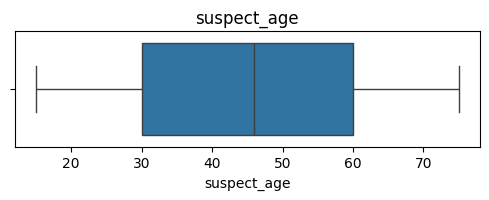

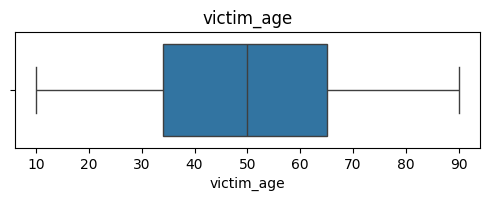

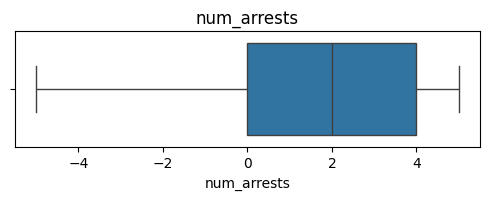

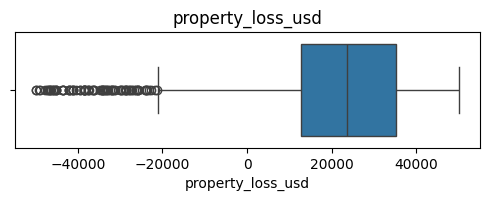

In [2024]:
numeric_cols = ['suspect_age', 'victim_age', 'num_arrests', 'property_loss_usd']
for i in numeric_cols:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(x=data[i])
    plt.title(i)
    plt.show()

In [2025]:
data['property_loss_usd'] = data['property_loss_usd'].abs()


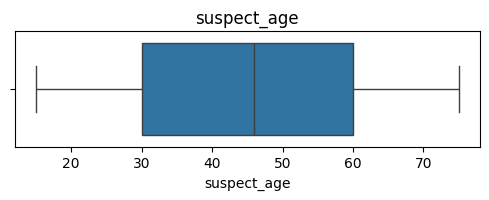

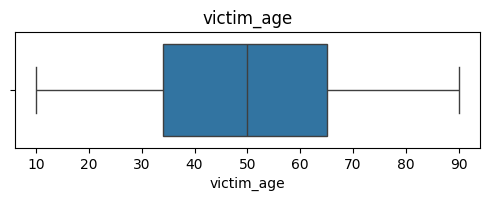

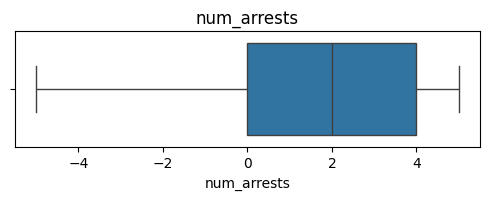

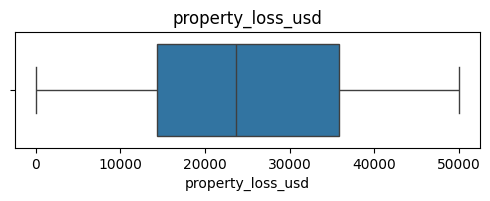

In [2026]:
numeric_cols = ['suspect_age', 'victim_age', 'num_arrests', 'property_loss_usd']
for i in numeric_cols:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(x=data[i])
    plt.title(i)
    plt.show()

In [2027]:
scalar= StandardScaler()
col=['suspect_age','victim_age']
data[col]=scalar.fit_transform(data[col])


In [2028]:
from sklearn.preprocessing import RobustScaler
scalar2= RobustScaler()
data['property_loss_usd'] = scalar2.fit_transform(data[['property_loss_usd']])
data

,crime_type,district,city,state,latitude,longitude,suspect_age,suspect_gender,suspect_race,victim_age,...,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online,reported_online_missing,incident_hour,incident_dayofweek,incident_month
0,319,696,622,503,0.000721,0.316035,0.323953,male,asian,0.061036,...,medium,open,No Arrest,0.0,0.000000,1,0,8.0,1.0,4.0
2,357,465,664,549,0.449250,-0.267271,-1.512358,female,asian,-0.983442,...,low,closed,Warning Issued,2.0,-0.359381,1,0,11.0,3.0,4.0
4,329,717,664,526,-0.365224,-0.902649,1.701186,female,white,0.061036,...,medium,closed,Warning Issued,2.0,-0.008601,1,0,20.0,5.0,7.0
5,329,473,621,501,1.237619,-0.354564,1.586417,unknown,white,-1.648109,...,high,under investigation,ArrestMade,1.0,0.000000,1,0,0.0,0.0,0.0
6,334,399,622,538,0.310363,-0.032036,0.725646,female,unknown,1.058037,...,unknown,closed,Warning Issued,3.0,0.000000,1,0,5.0,6.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5243,348,430,656,526,1.193289,-0.389735,-0.938511,male,white,1.912609,...,low,under investigation,Warning Issued,4.0,-0.464315,1,0,0.0,0.0,0.0
5244,369,535,622,495,0.889385,0.518121,-0.249894,female,hispanic,-0.935966,...,high,unknown,No Arrest,5.0,0.104432,1,0,5.0,2.0,3.0
5245,329,717,656,495,0.945524,0.252833,0.840416,female,white,1.627752,...,medium,unknown,ArrestMade,2.0,0.962710,0,1,17.0,5.0,12.0
5246,217,430,622,554,0.375606,-0.539817,-0.536818,unknown,hispanic,0.013559,...,medium,pending,unknown,5.0,-0.342325,0,0,4.0,4.0,6.0


In [2029]:
print(data['severity'].unique())

['medium' 'low' 'high' 'unknown' 'critical']


In [2030]:
from sklearn.preprocessing import OrdinalEncoder
order = [['unknown', 'low', 'medium', 'high', 'critical']]
data['severity'] = OrdinalEncoder(categories=order).fit_transform(data[['severity']])

In [2031]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['case_status'] = le.fit_transform(data['case_status'])

In [2032]:
catogrical_cols = ['suspect_gender', 'suspect_race', 'victim_gender', 'weapon_used', 'resolution']
data = pd.get_dummies(data, columns=catogrical_cols, drop_first=True, dtype=int)

In [2033]:
with pd.option_context('display.max_columns', None):
    print(data.head())

   crime_type  district  city  state  latitude  longitude  suspect_age  \
0         319       696   622    503  0.000721   0.316035     0.323953   
2         357       465   664    549  0.449250  -0.267271    -1.512358   
4         329       717   664    526 -0.365224  -0.902649     1.701186   
5         329       473   621    501  1.237619  -0.354564     1.586417   
6         334       399   622    538  0.310363  -0.032036     0.725646   

   victim_age  severity  case_status  num_arrests  property_loss_usd  \
0    0.061036       2.0            1          0.0           0.000000   
2   -0.983442       1.0            0          2.0          -0.359381   
4    0.061036       2.0            0          2.0          -0.008601   
5   -1.648109       3.0            4          1.0           0.000000   
6    1.058037       0.0            0          3.0           0.000000   

   reported_online  reported_online_missing  incident_hour  \
0                1                        0            8.0  

In [2034]:
X=data.drop('severity',axis=1)
Y=data['severity'] # inititally case status was my target but changing the target column to severity actually improves accuracy by 6 7 percent

In [2035]:
print(X.dtypes)

crime_type                     int64
district                       int64
city                           int64
state                          int64
latitude                     float64
longitude                    float64
suspect_age                  float64
victim_age                   float64
case_status                    int64
num_arrests                  float64
property_loss_usd            float64
reported_online                int64
reported_online_missing        int64
incident_hour                float64
incident_dayofweek           float64
incident_month               float64
suspect_gender_male            int64
suspect_gender_other           int64
suspect_gender_unknown         int64
suspect_race_black             int64
suspect_race_hispanic          int64
suspect_race_other             int64
suspect_race_unknown           int64
suspect_race_white             int64
victim_gender_male             int64
victim_gender_other            int64
victim_gender_unknown          int64
w

In [2036]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.20, random_state=42 )
model= LogisticRegression()
model.fit(X_train, Y_train)
Y_predict=model.predict(X_test)
accuracy_score(Y_predict, Y_test)

0.25654450261780104

In [2037]:
confusion_matrix(Y_test, Y_predict)

array([[  0,   0,  18,   0,  22],
       [  0,   0, 103,   0,  71],
       [  0,   0,  98,   0, 101],
       [  0,   0,  79,   0,  71],
       [  0,   1, 102,   0,  98]])

In [2038]:
print(classification_report(Y_test,Y_predict))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        40
         1.0       0.00      0.00      0.00       174
         2.0       0.24      0.49      0.33       199
         3.0       0.00      0.00      0.00       150
         4.0       0.27      0.49      0.35       201

    accuracy                           0.26       764
   macro avg       0.10      0.20      0.13       764
weighted avg       0.13      0.26      0.18       764



In [2039]:
from sklearn.naive_bayes import GaussianNB
model_nb = GaussianNB()
model_nb.fit(X_train, Y_train)
y_predict_nb = model_nb.predict(X_test)
accuracy_score(Y_test, y_predict_nb)


0.2630890052356021

In [2040]:
from sklearn.tree import DecisionTreeClassifier
model_tree= DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train,Y_train)
y_predict_tree = model_tree.predict(X_test)
accuracy_score(Y_test, y_predict_tree)


0.3036649214659686

In [2041]:
from sklearn.svm import SVC
model_svc= SVC(kernel='rbf') #maps the data into infinite dimeensions
model_svc.fit(X_train, Y_train)
y_predict_svc= model_svc.predict(X_test)
accuracy_score(Y_test, y_predict_svc)


0.24214659685863874

In [2042]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model_tree, X_train, Y_train,cv=5,scoring='accuracy')
scores

array([0.28594771, 0.28477905, 0.28150573, 0.25368249, 0.27659574])

In [2043]:
scores.mean()

np.float64(0.27650214477498586)

In [2044]:
imp = pd.Series(model_tree.feature_importances_, index=X_train.columns)
print(imp.sort_values(ascending=False).head(15))

longitude             0.093896
property_loss_usd     0.090032
latitude              0.080341
victim_age            0.075352
suspect_age           0.070801
crime_type            0.054210
incident_month        0.048299
state                 0.046936
district              0.046686
case_status           0.042641
incident_dayofweek    0.040483
incident_hour         0.039539
num_arrests           0.037883
city                  0.027169
victim_gender_male    0.019986
dtype: float64


Modeling note: Despite testing multiple classifiers (like: logistic regression, gaussianNB, 
decision tree, SVC) accuracy remained close to the random guessing baseline for a 5-class problem (20%).
Feature importance analysis confirmed no single feature carries strong predictive weight (max importance 9%),
suggesting the available features do not have a strong relationship with severity (/ case_status(initally it was tested)
in this dataset.so the dataset is best to use for data-cleaning practice rather than for realistic predictive modeling.